<a href="https://colab.research.google.com/github/flahbocchino/cardioia-fase4-visao-computacional/blob/main/fase4_parte1_preprocessamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CardioIA – Fase 4: Pré-processamento de Imagens Médicas

**Projeto:** CardioIA — Assistente Cardiológico Virtual  
**Fase:** 4 — Visão Computacional  
**Objetivo desta parte:** Preparar o pipeline de pré-processamento de imagens de raio-X de tórax para treinamento de modelos CNN.

**Dataset utilizado:** Chest X-Ray Images (Pneumonia) — Kaggle (Paul Mooney)  
**Classes:** NORMAL vs PNEUMONIA  
**Fonte:** https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

> ⚠️ **Aviso ético:** Este sistema classifica padrões em imagens médicas para fins exclusivamente acadêmicos. Não substitui avaliação médica profissional.

In [7]:
# Montar o Google Drive
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

# Caminho correto do ZIP no Drive
zip_path = '/content/drive/MyDrive/FORMAÇAO FIAP/chest_xray.zip'

# Descompactar para o Colab
print("Descompactando... aguarde.")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("\nEstrutura extraída:")
for root, dirs, files_list in os.walk('/content/chest_xray'):
    level = root.replace('/content/chest_xray', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files_list[:3]:
            print(f"{indent}  {f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Descompactando... aguarde.

Estrutura extraída:
chest_xray/
  train/
    NORMAL/
    PNEUMONIA/
  val/
    NORMAL/
    PNEUMONIA/
  test/
    NORMAL/
    PNEUMONIA/
  chest_xray/
    .DS_Store
    train/
      NORMAL/
      PNEUMONIA/
    val/
      NORMAL/
      PNEUMONIA/
    test/
      NORMAL/
      PNEUMONIA/


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')

# Caminhos do dataset
TRAIN_DIR = '/content/chest_xray/train'
VAL_DIR   = '/content/chest_xray/val'
TEST_DIR  = '/content/chest_xray/test'

# Parâmetros otimizados para Colab gratuito
IMG_SIZE   = (150, 150)
BATCH_SIZE = 32

print("Bibliotecas carregadas com sucesso.")
print(f"Tamanho das imagens: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")

Bibliotecas carregadas com sucesso.
Tamanho das imagens: (150, 150)
Batch size: 32


In [9]:
# Contagem de imagens por split e classe
for split, path in [('TREINO', TRAIN_DIR), ('VALIDAÇÃO', VAL_DIR), ('TESTE', TEST_DIR)]:
    normal    = len(os.listdir(os.path.join(path, 'NORMAL')))
    pneumonia = len(os.listdir(os.path.join(path, 'PNEUMONIA')))
    total     = normal + pneumonia
    print(f"\n📁 {split}")
    print(f"   NORMAL:    {normal:>5} imagens")
    print(f"   PNEUMONIA: {pneumonia:>5} imagens")
    print(f"   TOTAL:     {total:>5} imagens")


📁 TREINO
   NORMAL:     1341 imagens
   PNEUMONIA:  3875 imagens
   TOTAL:      5216 imagens

📁 VALIDAÇÃO
   NORMAL:        8 imagens
   PNEUMONIA:     8 imagens
   TOTAL:        16 imagens

📁 TESTE
   NORMAL:      234 imagens
   PNEUMONIA:   390 imagens
   TOTAL:       624 imagens


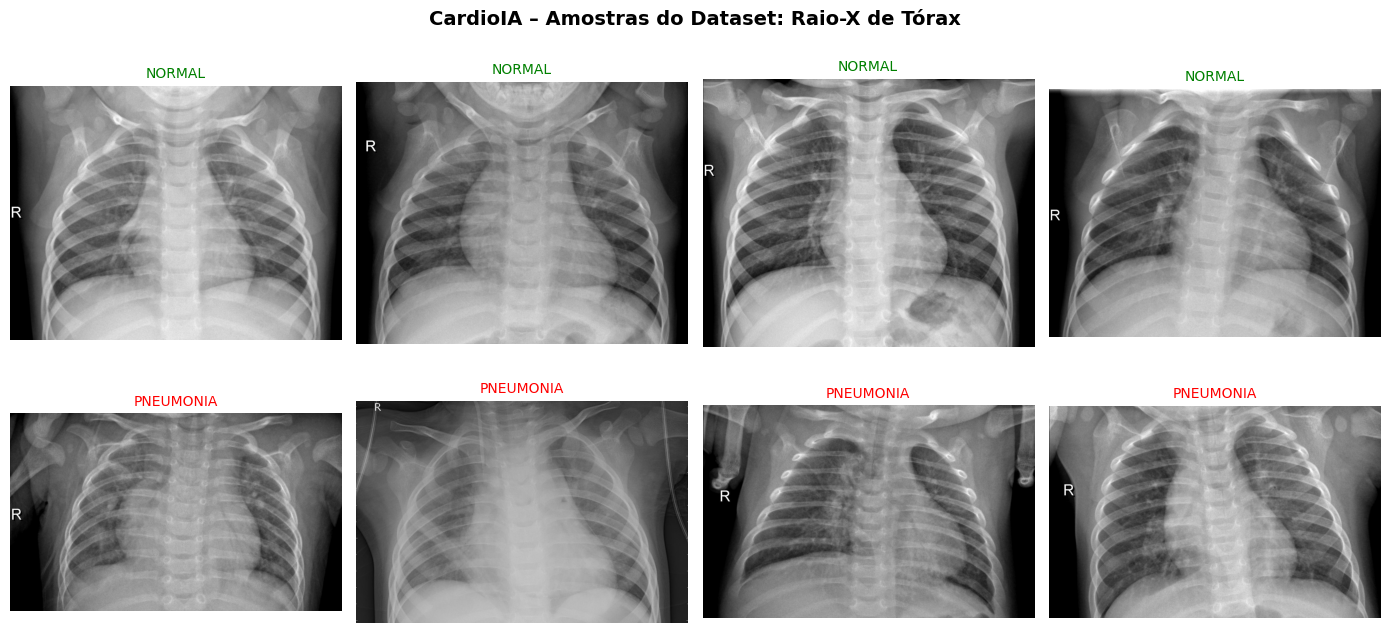

Imagem salva.


In [10]:
# Visualizar amostras do dataset
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('CardioIA – Amostras do Dataset: Raio-X de Tórax',
             fontsize=14, fontweight='bold')

for idx, classe in enumerate(['NORMAL', 'PNEUMONIA']):
    class_path = os.path.join(TRAIN_DIR, classe)
    images     = os.listdir(class_path)[:4]
    for j, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = mpimg.imread(img_path)
        axes[idx][j].imshow(img, cmap='gray')
        axes[idx][j].set_title(classe, fontsize=10,
                               color='green' if classe == 'NORMAL' else 'red')
        axes[idx][j].axis('off')

plt.tight_layout()
plt.savefig('/content/amostras_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print("Imagem salva.")

# Visualizar amostras do dataset
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('CardioIA – Amostras do Dataset: Raio-X de Tórax',
             fontsize=14, fontweight='bold')

for idx, classe in enumerate(['NORMAL', 'PNEUMONIA']):
    class_path = os.path.join(TRAIN_DIR, classe)
    images     = os.listdir(class_path)[:4]
    for j, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = mpimg.imread(img_path)
        axes[idx][j].imshow(img, cmap='gray')
        axes[idx][j].set_title(classe, fontsize=10,
                               color='green' if classe == 'NORMAL' else 'red')
        axes[idx][j].axis('off')

plt.tight_layout()
plt.savefig('/content/amostras_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print("Imagem salva.")

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentation apenas no treino
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Calcular class_weight para corrigir desbalanceamento
total = 1341 + 3875
class_weight = {
    0: total / (2 * 1341),  # NORMAL — classe minoritária
    1: total / (2 * 3875)   # PNEUMONIA
}

print(f"Classes: {train_gen.class_indices}")
print(f"Class weights: {class_weight}")
print(f"\nTreino:    {train_gen.samples} imagens")
print(f"Validação: {val_gen.samples} imagens")
print(f"Teste:     {test_gen.samples} imagens")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}

Treino:    5216 imagens
Validação: 16 imagens
Teste:     624 imagens


## Pipeline de Pré-processamento — Resumo

| Etapa | Descrição |
|---|---|
| Redimensionamento | 150x150 pixels |
| Normalização | Pixels divididos por 255 (escala 0-1) |
| Augmentation | Rotação, zoom, flip horizontal |
| Correção de desbalanceamento | class_weight proporcional |
| Split | Treino / Validação / Teste já fornecidos pelo dataset |